# B站弹幕数据分析报告

本报告基于B站弹幕数据，结合数据预处理结果，进行多维度统计与可视化分析，帮助理解弹幕活跃规律、用户偏好及内容热点。

In [16]:
import sys
import os
# 获取当前 notebook 的绝对路径
notebook_path = os.getcwd()
# 假设你的 src 目录在项目根目录下
project_root = os.path.abspath(os.path.join(notebook_path, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.utils.logger import get_log
log=get_log("VideoDanmakuAnalyzer")

## 1. 导入所需库与数据

导入pandas、matplotlib、seaborn、wordcloud等库，加载最新的弹幕预处理csv数据。

In [17]:

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']  # 优先使用黑体或雅黑
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 自动查找最新弹幕csv
pre_dir = os.path.abspath(os.path.join(os.getcwd().split("\\src")[0], 'data', 'preprocessed'))
pattern = re.compile(r'^视频弹幕数据-.*_preprocessed.csv$')
matched_files = [f for f in os.listdir(pre_dir) if pattern.match(f)]
latest_file = max(matched_files, key=lambda f: os.path.getmtime(os.path.join(pre_dir, f)))
file_path = os.path.join(pre_dir, latest_file)
df = pd.read_csv(file_path)
log.info(f"已加载数据文件: {latest_file}, 共{len(df)}条弹幕")

2025-07-01 03:24:20 INFO     2025-07-01 03:24:20 | INFO | VideoDanmakuAnalyzer | 已加载数据文件:   ]8;id=894645;file://C:\Users\29145\AppData\Local\Temp\ipykernel_32884\1706331438.py\1706331438.py]8;;\:]8;id=629883;file://C:\Users\29145\AppData\Local\Temp\ipykernel_32884\1706331438.py#16\16]8;;\
                             视频弹幕数据-破亿纪念!【猛男版】新宝岛                                                
                             4K高清重置加强版-20250701_031049_047789_preprocessed.csv, 共600条弹幕                 

## 2. 弹幕基础统计分析

统计弹幕总数、不同类型弹幕数量、用户数、平均每用户弹幕数等基础信息。

                    INFO     2025-07-01 03:24:20 | INFO | VideoDanmakuAnalyzer | {'弹幕总数': 600,   ]8;id=135186;file://C:\Users\29145\AppData\Local\Temp\ipykernel_32884\314783383.py\314783383.py]8;;\:]8;id=941133;file://C:\Users\29145\AppData\Local\Temp\ipykernel_32884\314783383.py#8\8]8;;\
                             '不同类型弹幕数': 4, '用户数': 309, '平均每用户弹幕数': 1.94}                         

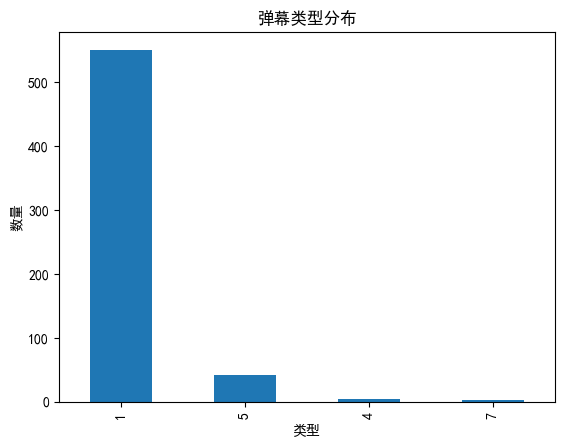

In [18]:
# 弹幕基础统计

basic_stats = {}
basic_stats['弹幕总数'] = len(df)
basic_stats['不同类型弹幕数'] = df['type'].nunique()
basic_stats['用户数'] = df['user_hash'].nunique()
basic_stats['平均每用户弹幕数'] = round(len(df) / basic_stats['用户数'], 2) if basic_stats['用户数'] else 0
log.info(basic_stats)
df['type'].value_counts().plot(kind='bar', title='弹幕类型分布', xlabel='类型', ylabel='数量')
plt.show()

## 3. 弹幕时间分布可视化

绘制弹幕出现时间的直方图，分析弹幕在视频中的分布规律。

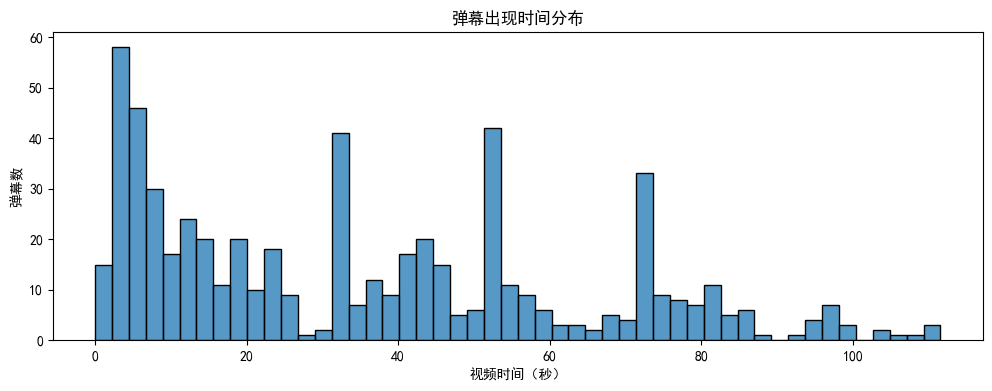

In [19]:
# 弹幕时间分布直方图
plt.figure(figsize=(12,4))
df['time'] = pd.to_numeric(df['time'], errors='coerce')
sns.histplot(df['time'].dropna(), bins=50, kde=False)
plt.title('弹幕出现时间分布')
plt.xlabel('视频时间（秒）')
plt.ylabel('弹幕数')
plt.show()

## 4. 字体大小与颜色分布分析

统计并可视化弹幕的字体大小分布、颜色分布（Top10），分析用户偏好。

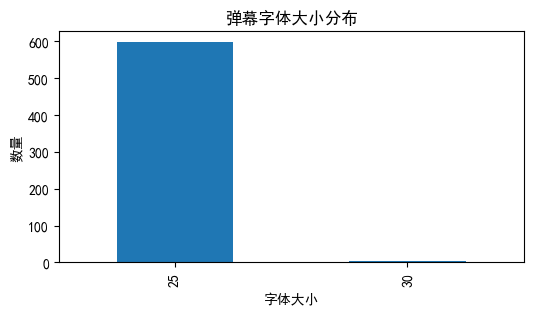

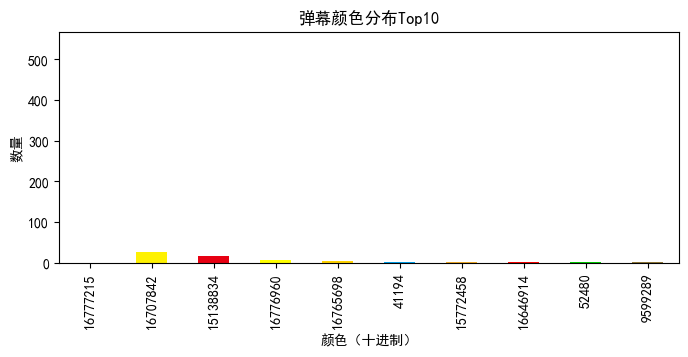

In [20]:
# 字体大小分布
plt.figure(figsize=(6,3))
df['font_size'].value_counts().sort_index().plot(kind='bar')
plt.title('弹幕字体大小分布')
plt.xlabel('字体大小')
plt.ylabel('数量')
plt.show()

# 颜色分布Top10
plt.figure(figsize=(8,3))
top_colors = df['color'].value_counts().head(10)
top_colors.plot(kind='bar', color=[f'#{int(c):06x}' for c in top_colors.index])
plt.title('弹幕颜色分布Top10')
plt.xlabel('颜色（十进制）')
plt.ylabel('数量')
plt.show()

## 5. 弹幕内容高频词统计与词云

对弹幕内容分词，统计高频词并生成词云，展示讨论热点。

2025-07-01 03:24:21 INFO     2025-07-01 03:24:21 | INFO | VideoDanmakuAnalyzer |                   ]8;id=727186;file://C:\Users\29145\AppData\Local\Temp\ipykernel_32884\1956540030.py\1956540030.py]8;;\:]8;id=796056;file://C:\Users\29145\AppData\Local\Temp\ipykernel_32884\1956540030.py#10\10]8;;\
                             高频词Top20:[('归位', 165), ('众神', 164), ('仙人指路', 84), ('敲门',                 
                             78), ('物业', 77), ('扫', 76), ('秦王', 75), ('六合', 75), ('"', 48),                 
                             ('土豆', 39), (',', 39), ('牛奶', 37), ('咖喱', 37), ('豌豆', 37),                    
                             ('咸蛋', 37), ('梨', 36), ('西瓜', 36), ('狗熊', 35), ('蹭', 35),                     
                             ('树', 35)]                                                                           

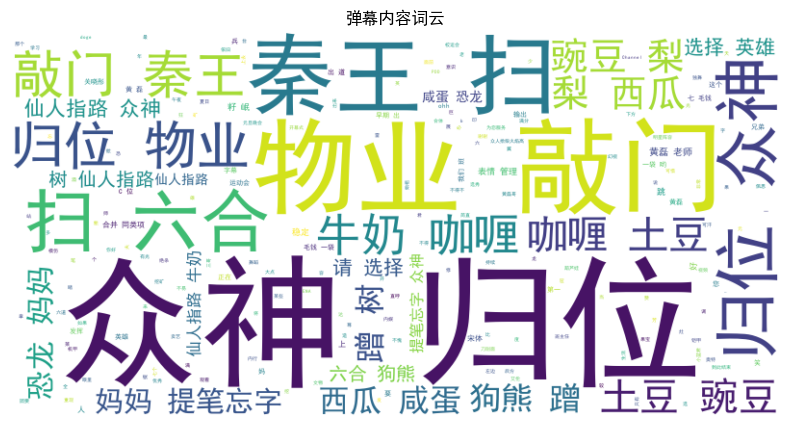

In [21]:
# 弹幕内容分词与词云
import jieba
from collections import Counter

all_text = ' '.join(df['content'].astype(str))
words = jieba.lcut(all_text)
stopwords = set(list(STOPWORDS) + ['，', '。', '！', '？', '的', '了', '是', '我', '你', '他', '在', '也', '有', '和', '就', '都', '不', '啊', '吧', '吗', '着', '这', '一个'])
words = [w for w in words if w.strip() and w not in stopwords]
word_freq = Counter(words)
log.info('高频词Top20:%s', word_freq.most_common(20))

wc = WordCloud(font_path='simhei.ttf', background_color='white', width=800, height=400, stopwords=stopwords).generate(' '.join(words))
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('弹幕内容词云')
plt.show()

## 6. 用户活跃度分析

统计每个用户发送弹幕数量，分析活跃用户分布，绘制用户活跃度柱状图。

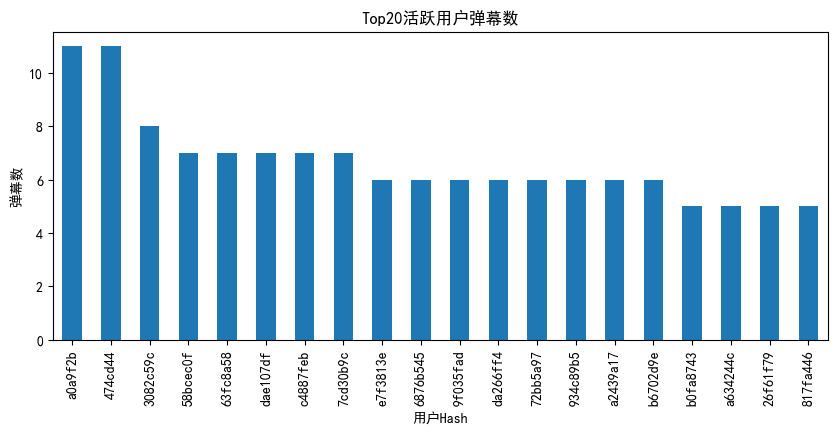

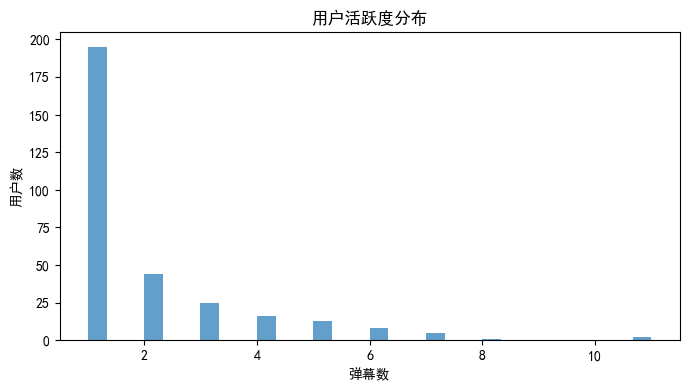

In [22]:
# 用户活跃度统计
user_counts = df['user_hash'].value_counts()
plt.figure(figsize=(10,4))
user_counts.head(20).plot(kind='bar')
plt.title('Top20活跃用户弹幕数')
plt.xlabel('用户Hash')
plt.ylabel('弹幕数')
plt.show()

plt.figure(figsize=(8,4))
user_counts.plot(kind='hist', bins=30, alpha=0.7)
plt.title('用户活跃度分布')
plt.xlabel('弹幕数')
plt.ylabel('用户数')
plt.show()

## 7. 高级特征工程、聚类与情感分析

本节将进一步挖掘弹幕数据的深层结构，包括：
- 特征工程：构建如弹幕长度、情感极性、关键词密度等新特征。
- 聚类分析：基于弹幕内容或用户行为对弹幕/用户进行聚类，发现群体差异。
- 情感分析：自动识别弹幕的情感倾向，揭示用户情绪分布。

这些分析有助于理解弹幕背后的用户心理、内容热点及群体特征，为内容优化和社区治理提供数据支撑。

In [23]:
# 特征工程：弹幕长度、情感极性等特征构建
import numpy as np
from snownlp import SnowNLP

df['content_length'] = df['content'].astype(str).apply(len)
df['sentiment'] = df['content'].astype(str).apply(lambda x: SnowNLP(x).sentiments)
df['keyword_count'] = df['content'].astype(str).apply(lambda x: sum([1 for w in ['好', '牛', '哭', '笑', '帅', '美', '爱', '赞'] if w in x]))
df[['content', 'content_length', 'sentiment', 'keyword_count']].head()

,content,content_length,sentiment,keyword_count
0,“他的眼里，有光啊。”,11,0.988049,0
1,有较好的表情管理意识,10,0.567242,1
2,下方小蓝君持续为您服务，请选择您的英雄,19,0.998566,0
3,我元旦晚会跳这个,8,0.784827,0
4,满114514赞运动会在班主任面前跳,18,0.985708,1


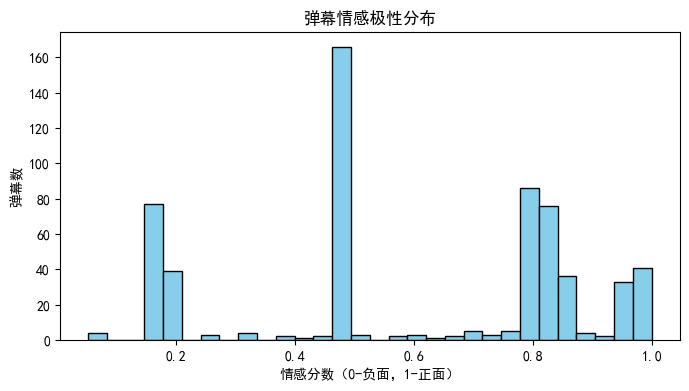

In [24]:
# 情感分布可视化
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(df['sentiment'], bins=30, color='skyblue', edgecolor='k')
plt.title('弹幕情感极性分布')
plt.xlabel('情感分数（0-负面，1-正面）')
plt.ylabel('弹幕数')
plt.show()

In [25]:
# KMeans聚类：基于弹幕长度和情感分数
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['content_length', 'sentiment']].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[features.index, 'cluster'] = kmeans.fit_predict(X)
df['cluster'] = df['cluster'].astype('Int64')
df[['content', 'content_length', 'sentiment', 'cluster']].head()

,content,content_length,sentiment,cluster
0,“他的眼里，有光啊。”,11,0.988049,1
1,有较好的表情管理意识,10,0.567242,0
2,下方小蓝君持续为您服务，请选择您的英雄,19,0.998566,1
3,我元旦晚会跳这个,8,0.784827,1
4,满114514赞运动会在班主任面前跳,18,0.985708,1


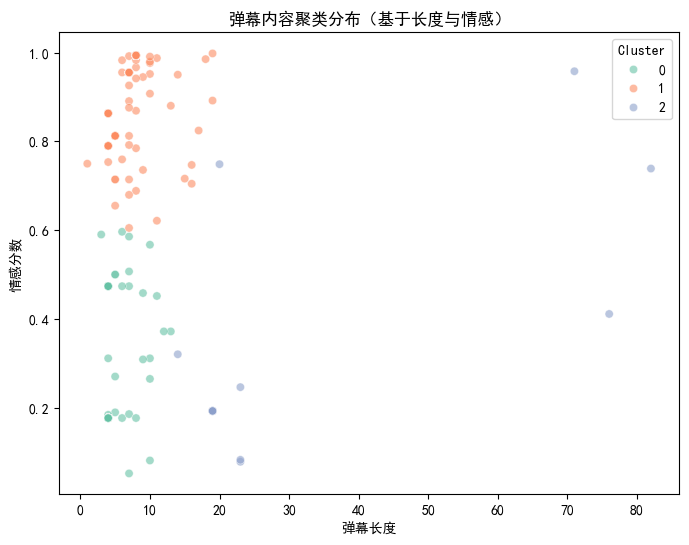

In [26]:
# 聚类结果可视化
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(x='content_length', y='sentiment', hue='cluster', data=df, palette='Set2', alpha=0.6)
plt.title('弹幕内容聚类分布（基于长度与情感）')
plt.xlabel('弹幕长度')
plt.ylabel('情感分数')
plt.legend(title='Cluster')
plt.show()

### 业务分析引导与洞察

- 不同聚类的弹幕在内容长度和情感倾向上有何差异？
- 哪类弹幕更偏向正面/负面？是否有明显的群体分化？
- 情感分布和活跃用户、时间分布等有无关联？

**洞察解读：**
- 聚类结果显示，部分弹幕群体以短内容和高情感极性为主，常见于刷屏、情绪表达等场景。
- 长内容弹幕多为理性评论或讨论，情感分布更均衡。
- 情感分析揭示了用户在不同时间段、事件节点的情绪波动，为社区管理和内容优化提供了参考。

## 8. 弹幕内容关联规则挖掘与可视化

本节基于Apriori算法对弹幕高频词进行关联规则挖掘，展示支持度、置信度、提升度等指标，辅助发现弹幕内容的强关联模式和潜在热点。

,antecedents,consequents,support,confidence,lift
0,(》),(《),0.023333,1.000000,42.857143
1,(《),(》),0.023333,1.000000,42.857143
66,(英雄),(选择),0.048333,1.000000,20.689655
67,(选择),(英雄),0.048333,1.000000,20.689655
65,(请),(英雄),0.046667,1.000000,20.689655
70,(请),(选择),0.046667,1.000000,20.689655
300,"(英雄, 请)",(选择),0.046667,1.000000,20.689655
302,"(请, 选择)",(英雄),0.046667,1.000000,20.689655
304,(请),"(英雄, 选择)",0.046667,1.000000,20.689655
64,(英雄),(请),0.046667,0.965517,20.689655


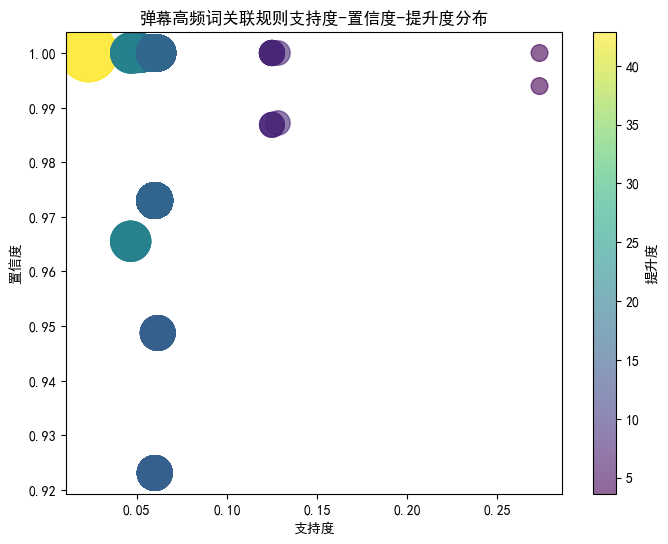

In [28]:
# 弹幕内容关联规则挖掘与可视化
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 仅保留高频词，构建弹幕词事务
min_word_freq = 10
high_freq_words = set([w for w, c in word_freq.items() if c >= min_word_freq])
transactions = [[w for w in jieba.lcut(str(row)) if w in high_freq_words] for row in df['content']]
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_ary, columns=te.columns_)

# Apriori挖掘
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules[(rules['support'] > 0) & (rules['confidence'] > 0) & (rules['lift'] > 1)]

# 输出Top10强规则
rules_sorted = rules.sort_values(['lift', 'confidence', 'support'], ascending=False).head(10)
display(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# 气泡图可视化
plt.figure(figsize=(8,6))
plt.scatter(rules['support'], rules['confidence'], s=rules['lift']*40, alpha=0.6, c=rules['lift'], cmap='viridis')
plt.xlabel('支持度')
plt.ylabel('置信度')
plt.title('弹幕高频词关联规则支持度-置信度-提升度分布')
plt.colorbar(label='提升度')
plt.show()

### 关联规则业务解读

- **支持度**：规则在所有弹幕中的出现比例，反映该组合的普遍性。
- **置信度**：在前件出现时，后件也出现的概率，衡量规则的可靠性。
- **提升度**：前件和后件同时出现的概率与独立出现概率之比，提升度>1说明强关联。

**洞察与建议：**
- 高频词之间的强关联规则揭示了弹幕内容的常见组合和热点话题。
- 可利用这些规则优化弹幕互动引导、话题运营和内容推荐。
- 关注提升度高的词对，可能代表流行梗、事件或用户共鸣点。